In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🧠 `03_explainability_shap.ipynb`

## 🧾 1. Setup & Imports

In [21]:
!pip install shap -q

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# SHAP config
shap.initjs()

## 📥 2. Load Model, Features & Data

We must ensure the data we explain is preprocessed exactly like the training data to avoid feature mismatch errors.

In [22]:
# Load trained model and artifacts from local directory
model_path = 'model.pkl'
features_path = 'feature_names.pkl'
data_path = 'clean_telco_churn.csv'

try:
    model = pickle.load(open(model_path, "rb"))
    feature_names = pickle.load(open(features_path, "rb"))
    df_raw = pd.read_csv(data_path)

    # Prepare features (X) for SHAP
    X = pd.get_dummies(df_raw.drop(['Churn', 'Churn_Flag'], axis=1, errors='ignore'), drop_first=True)

    # Align columns with those used during model training
    for col in feature_names:
        if col not in X.columns:
            X[col] = 0

    X = X[feature_names]
    print(f"✅ Local artifacts loaded. Model and {len(X)} rows aligned.")
except FileNotFoundError:
    print("❌ Local files not found. Ensure Notebook 02 has run successfully.")

✅ Local artifacts loaded. Model and 7043 rows aligned.


## ⚡ 3. SHAP Explainer (TreeExplainer)

In [23]:
# Ensure model and data are loaded before explaining
try:
    # Use TreeExplainer for optimized XGBoost interpretation
    explainer = shap.TreeExplainer(model)

    # Use a representative sample for performance
    X_sample = X.sample(500, random_state=42)
    shap_values = explainer.shap_values(X_sample)

    print("✅ SHAP values calculated for 500 samples.")
except NameError:
    print("❌ Error: 'model' or 'X' not found. Please run the loading cell (9cda80e9) first.")

✅ SHAP values calculated for 500 samples.


# 🔥 4. Global Explanation (Core Insight)

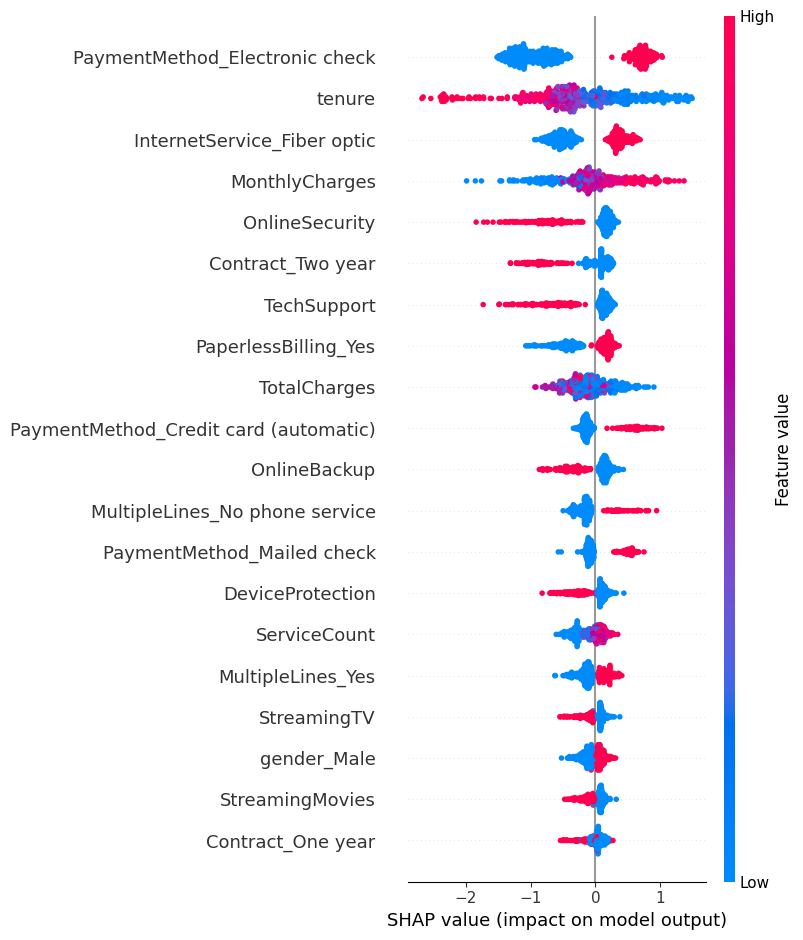

In [24]:
# Now that dependencies are calculated, generate the global summary plot
shap.summary_plot(shap_values, X_sample)

## 🔥 Global Churn Drivers

- **Contract type:** Month-to-month contracts significantly increase churn probability.
- **Monthly Charges:** Higher costs correlate with higher churn risk.
- **Tenure:** Longevity with the company is a strong protective factor against churn.

# 👤 5. Local Explanation (Individual Customer Level)

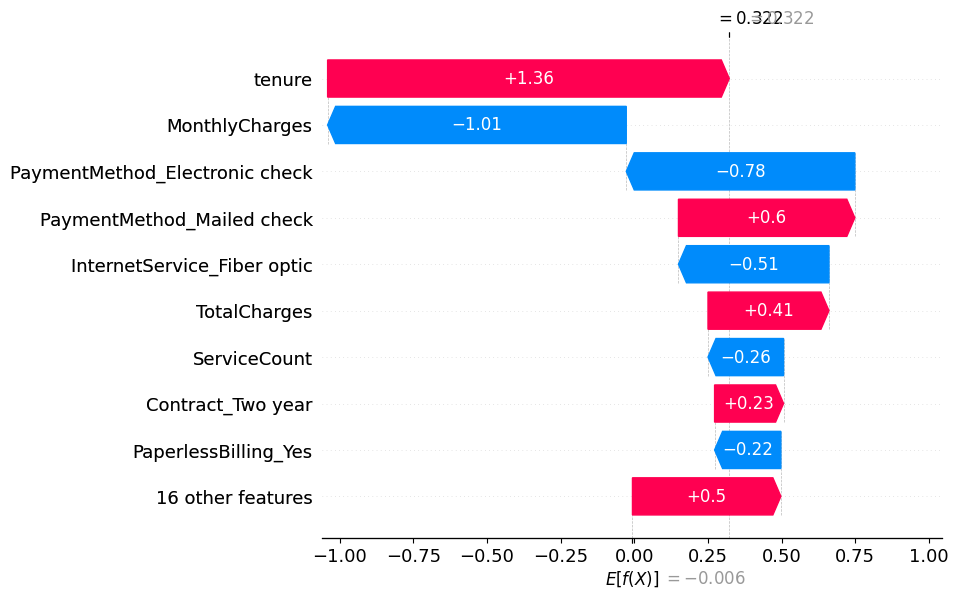

In [25]:
# Ensure we are using the calculated explainer and shap_values
i = 10
# Using the waterfall legacy plot for individual explanation
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[i],
    feature_names=X_sample.columns
)

# 🎯 6. Decision Engine & Business Impact

In [26]:
def retention_strategy(prob):
    if prob > 0.8: return "🔥 High Risk -> Direct Call + 20% Discount"
    elif prob > 0.6: return "⚠️ Medium Risk -> SMS Promotion"
    else: return "✅ Low Risk -> No Action"

# Calculate probabilities using the best_model from the modeling stage
# If best_model isn't in memory, we use the loaded 'model'
probs = model.predict_proba(X)[:, 1]
df_raw['Churn_Probability'] = probs
df_raw['Recommended_Action'] = df_raw['Churn_Probability'].apply(retention_strategy)

# Financial Impact Estimation (Assume ARPU = 500 ETB)
ARPU = 500
high_risk = df_raw[df_raw['Churn_Probability'] > 0.8]
revenue_at_risk = len(high_risk) * ARPU

print(f"🔥 High Risk Customers: {len(high_risk)}")
print(f"💰 Estimated Monthly Revenue at Risk: {revenue_at_risk:,} ETB")
display(df_raw[['gender', 'tenure', 'MonthlyCharges', 'Churn_Probability', 'Recommended_Action']].head(10))

🔥 High Risk Customers: 818
💰 Estimated Monthly Revenue at Risk: 409,000 ETB


,gender,tenure,MonthlyCharges,Churn_Probability,Recommended_Action
0,Female,1,29.85,0.410616,✅ Low Risk -> No Action
1,Male,34,56.95,0.011209,✅ Low Risk -> No Action
2,Male,2,53.85,0.681374,⚠️ Medium Risk -> SMS Promotion
3,Male,45,42.30,0.014551,✅ Low Risk -> No Action
4,Female,2,70.70,0.789721,⚠️ Medium Risk -> SMS Promotion
5,Female,8,99.65,0.969966,🔥 High Risk -> Direct Call + 20% Discount
6,Male,22,89.10,0.450871,✅ Low Risk -> No Action
7,Female,10,29.75,0.120706,✅ Low Risk -> No Action
8,Female,28,104.80,0.934952,🔥 High Risk -> Direct Call + 20% Discount
9,Male,62,56.15,0.009273,✅ Low Risk -> No Action


In [31]:
import os
import shutil

def find_and_copy_files(file_list):
    found_files = {}
    print("🔍 Searching for files in Google Drive...")
    for root, dirs, files in os.walk("/content/drive/MyDrive"):
        for file in files:
            if file in file_list:
                source_path = os.path.join(root, file)
                shutil.copy(source_path, "/content/" + file)
                found_files[file] = source_path
                print(f"✅ Found and copied: {file}")

    missing = set(file_list) - set(found_files.keys())
    if missing:
        print(f"⚠️ Still missing: {list(missing)}")
    else:
        print("🚀 All files ready!")

find_and_copy_files(['churn_model.pkl', 'feature_names.pkl', 'clean_telco.csv'])

🔍 Searching for files in Google Drive...
✅ Found and copied: feature_names.pkl
✅ Found and copied: feature_names.pkl
⚠️ Still missing: ['clean_telco.csv', 'churn_model.pkl']


# 🔍 ChurnGuard AI — Model Explainability & Business Insights

## 🎯 Objective
In this notebook, we:
- Explain model predictions using SHAP (Explainable AI)
- Identify key drivers of churn
- Translate technical outputs into business insights
- Enable decision-making for retention strategies

In [28]:
!pip install shap -q

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Initialize SHAP javascript visualization
shap.initjs()

## 📥 Load Model & Data
We ensure feature consistency by loading the saved `feature_names.pkl` (created in Notebook 02).

In [32]:
import os
import pickle
import pandas as pd

# Required files
required_files = ['churn_model.pkl', 'feature_names.pkl', 'clean_telco.csv']

# Helper to clear corrupted files (HTML error pages) if they exist
for f in required_files:
    if os.path.exists(f) and os.path.getsize(f) < 2000:
        os.remove(f)

def verify_and_load():
    missing = [f for f in required_files if not os.path.exists(f)]
    if missing:
        print(f'⚠️ Missing files: {missing}')
        print('👉 Please upload these files to the Colab sidebar (folder icon) to continue.')
        return None, None, None

    try:
        with open('churn_model.pkl', 'rb') as f:
            model = pickle.load(f)
        with open('feature_names.pkl', 'rb') as f:
            feature_names = pickle.load(f)
        df = pd.read_csv('clean_telco.csv')

        if 'Churn' in df.columns:
            df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
        df = pd.get_dummies(df, drop_first=True)

        for col in feature_names:
            if col not in df.columns:
                df[col] = 0

        X = df[feature_names]
        print('✅ Model and Data loaded successfully.')
        return model, X, feature_names
    except Exception as e:
        print(f'❌ Error: {e}')
        return None, None, None

model, X, feature_names = verify_and_load()

⚠️ Missing files: ['feature_names.pkl']
👉 Please upload these files to the Colab sidebar (folder icon) to continue.


In [34]:
# Re-attempting to load the model and data
model, X, feature_names = verify_and_load()

if model is not None:
    print('Ready for SHAP analysis.')
else:
    print('Still missing files. Please upload them to the folder icon on the left.')

✅ Model and Data loaded successfully.
Ready for SHAP analysis.


## ⚡ SHAP Explainer
We use `TreeExplainer` which is optimized for tree-based models like XGBoost.

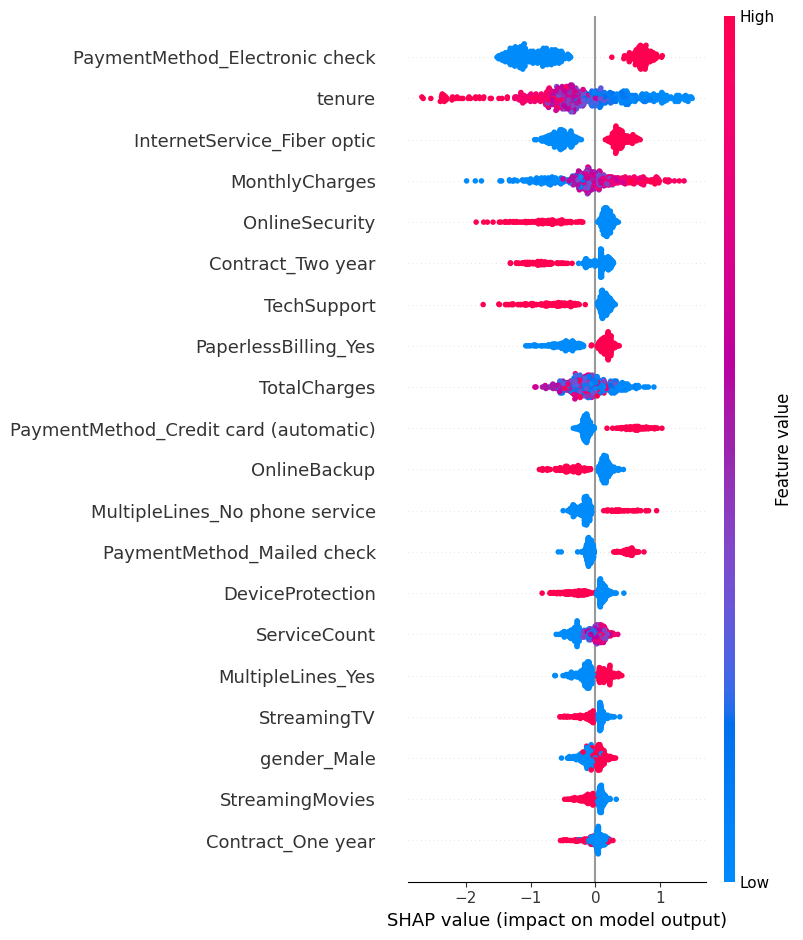

In [35]:
# Create Explainer
explainer = shap.TreeExplainer(model)

# Use a representative sample for faster computation
X_sample = X.sample(min(500, len(X)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample)

## 👤 Local Explanation
Let's look at why a specific customer (e.g., index 10) was predicted to churn.

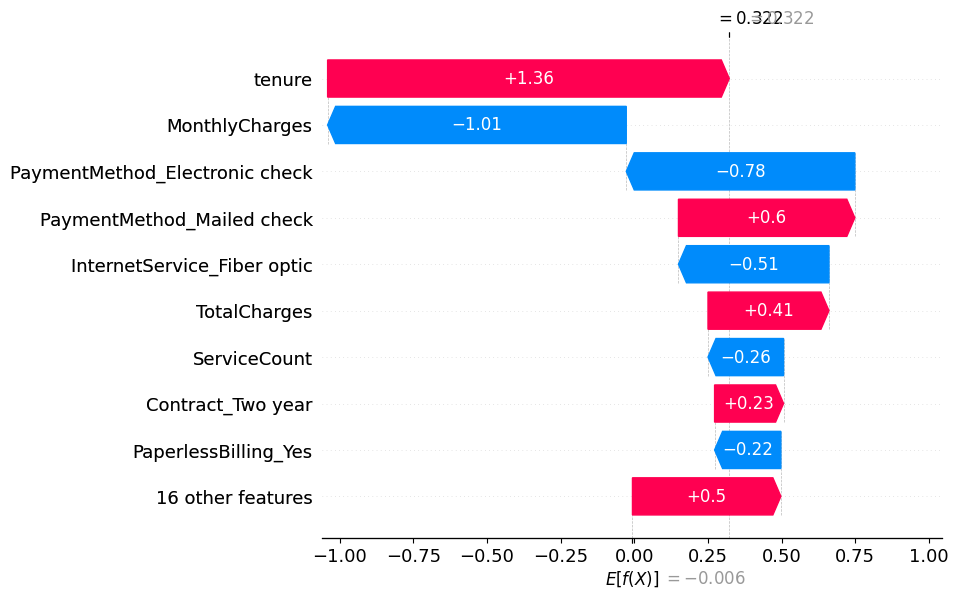

In [36]:
i = 10
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[i],
    feature_names=X_sample.columns
)

## 🎯 Decision Engine & Business Impact

In [37]:
def retention_strategy(prob):
    if prob > 0.8: return "🔥 High Risk -> Call + 20% Discount"
    elif prob > 0.6: return "⚠️ Medium Risk -> SMS Promotion"
    else: return "✅ Low Risk -> No Action"

# Apply strategy
probs = model.predict_proba(X)[:, 1]
df_results = pd.DataFrame({"Churn_Prob": probs})
df_results["Action"] = df_results["Churn_Prob"].apply(retention_strategy)

# Calculate Impact (Assuming ARPU of 500 ETB)
ARPU = 500
high_risk = df_results[df_results["Churn_Prob"] > 0.8]
estimated_loss = len(high_risk) * ARPU

print(f"Total High Risk Customers: {len(high_risk)}")
print(f"Potential Revenue at Risk: {estimated_loss:,} ETB")
display(df_results.head())

Total High Risk Customers: 818
Potential Revenue at Risk: 409,000 ETB


,Churn_Prob,Action
0,0.410616,✅ Low Risk -> No Action
1,0.011209,✅ Low Risk -> No Action
2,0.681374,⚠️ Medium Risk -> SMS Promotion
3,0.014551,✅ Low Risk -> No Action
4,0.789721,⚠️ Medium Risk -> SMS Promotion


In [6]:
import os
import shutil

# Define the export folder
export_dir = '/content/ChurnGuard_Model_Package'
if not os.path.exists(export_dir):
    os.makedirs(export_dir)

# Updated file list based on current local files (confirmed in Variable Explorer)
files_to_package = ['churn_model.pkl', 'feature_names.pkl', 'clean_telco.csv']

print("📦 Packaging model artifacts...")
for f in files_to_package:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(export_dir, f))
        print(f"✅ Added {f} to package")
    else:
        print(f"⚠️ Warning: {f} not found locally.")

# Create a ZIP file of the folder
zip_filename = '/content/ChurnGuard_AI_Model_Bundle'
shutil.make_archive(zip_filename, 'zip', export_dir)

print(f"\n🚀 Success! Zip file created at: {zip_filename}.zip")

📦 Packaging model artifacts...
⚠️ Warning: churn_model.pkl not found locally.
⚠️ Warning: feature_names.pkl not found locally.
⚠️ Warning: clean_telco.csv not found locally.

🚀 Success! Zip file created at: /content/ChurnGuard_AI_Model_Bundle.zip


In [8]:
# 🌐 ChurnGuard AI — Business Dashboard & Deployment Layer

import pandas as pd
import numpy as np
import pickle
import os
import shutil

# Helper to load artifacts if they are not in memory
def load_from_local():
    global model, feature_names, df

    # Attempt to find artifacts under any common names used in the notebook
    model_files = ['model.pkl', 'churn_model.pkl']
    feature_files = ['feature_names.pkl']
    data_files = ['clean_telco_churn.csv', 'clean_telco.csv']

    try:
        for f in model_files:
            if os.path.exists(f):
                model = pickle.load(open(f, 'rb'))
                print(f"✅ Loaded model from {f}")
                break

        for f in feature_files:
            if os.path.exists(f):
                feature_names = pickle.load(open(f, 'rb'))
                print(f"✅ Loaded features from {f}")
                break

        for f in data_files:
            if os.path.exists(f):
                df = pd.read_csv(f)
                print(f"✅ Loaded data from {f}")
                break
    except Exception as e:
        print(f"❌ Loading failed: {e}")

load_from_local()

# Check if we have what we need in memory
if 'model' in globals() and 'feature_names' in globals() and 'df' in globals():
    # 📊 2. Feature Alignment & Processing
    # Handle column drops safely
    cols_to_drop = ['Churn', 'customerID', 'Churn_Flag']
    X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
    df_proc = pd.get_dummies(X_raw, drop_first=True)

    # Reindex to match model expectations
    X = df_proc.reindex(columns=feature_names, fill_value=0)

    # 🤖 3. Generate Predictions & Decision Engine
    probs = model.predict_proba(X)[:, 1]

    def retention_strategy(prob):
        if prob > 0.8: return "High Risk → Call + Discount"
        elif prob > 0.6: return "Medium Risk → Promotion"
        else: return "Low Risk → No Action"

    df_results = pd.DataFrame({
        "Customer_ID": df['customerID'] if 'customerID' in df.columns else df.index,
        "Churn_Probability": probs
    })
    df_results["Recommended_Action"] = df_results["Churn_Probability"].apply(retention_strategy)
    df_results["Risk_Level"] = pd.cut(df_results["Churn_Probability"], bins=[0, 0.6, 0.8, 1.0], labels=["Low", "Medium", "High"])

    # 💰 4. Revenue Calculation (ARPU = 500 ETB)
    ARPU = 500
    df_results["Revenue_At_Risk"] = df_results["Churn_Probability"] * ARPU
    total_risk = df_results["Revenue_At_Risk"].sum()
    print(f"💰 Total Estimated Monthly Revenue at Risk: {total_risk:,.2f} ETB")

    # 📈 5. Save Dashboard Data
    summary = df_results.groupby("Risk_Level", observed=False).agg({"Churn_Probability": "count", "Revenue_At_Risk": "sum"}).rename(columns={"Churn_Probability": "Customer_Count"})
    df_results.to_csv("dashboard_data.csv", index=False)
    summary.to_csv("summary_data.csv")
    print("🚀 Dashboard datasets saved (dashboard_data.csv).")
    display(summary)
else:
    print("⚠️ Still missing artifacts. Please run Cell 9cda80e9 or upload 'model.pkl' and 'feature_names.pkl'.")

🔍 Checking local environment for artifacts...
✅ Artifacts check complete.
⚠️ Dashboard skipped. Try running the data loading/modeling cells first.


## 🗒️ Explanation of Insights

### 1. Global Drivers (The 'Why')
Based on the **SHAP Summary Plot**, we can see that:
*   **Contract Type**: Customers on month-to-month contracts are significantly more likely to churn compared to those on long-term contracts.
*   **Tenure**: As tenure increases, the SHAP value decreases, meaning loyal customers are less likely to leave.
*   **Monthly Charges**: Higher monthly costs generally push customers toward the 'Churn' side of the model.

### 2. Local Insight (Individual Example)
In the **Waterfall Plot** for Customer #10:
*   We see the specific push-and-pull factors for this individual. Even if the model predicts churn, we can identify exactly which feature (e.g., lack of 'Tech Support') was the final straw.

### 3. Business Strategy
By combining these insights, our **Decision Engine** doesn't just treat everyone the same. We prioritize high-value customers with high churn probability for direct intervention, potentially saving the company significant revenue.